In [1]:
from models.clustering import DeepEmbeddingClustering
from models.decomposition import Autoencoder
from models.user import UserFeaturePreprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

pd.options.display.max_columns = None

In [2]:
users  = pd.read_csv("./data/KuaiRand-1K/data/user_features_1k.csv")

In [19]:
device = "mps"

encoder = Pipeline([
    ('preprocessor', UserFeaturePreprocessor),
    ('scaler', MinMaxScaler()),
    ('encoder', Autoencoder(
        encoder=[
            nn.Linear(34, 24), nn.ReLU(), 
            nn.Linear(24, 7), nn.ReLU(), 
            nn.Linear(7, 2)], 
        decoder=[
            nn.Linear(2, 7), nn.ReLU(), 
            nn.Linear(7, 24), nn.ReLU(), 
            nn.Linear(24, 34)], 
        lr=1e-3, 
        batch_size=100, 
        epochs=100, 
        min_delta=1e-9, 
        device=device
    ))
])

clustering = Pipeline([
    ('standardize', StandardScaler()),
    ('cluster', DeepEmbeddingClustering( n_clusters=25, epochs=100, device=device ))
])

X = users.drop('user_id', axis=1)
model = Pipeline([
    ('encoder', encoder),
    ('clustering', clustering)
])
model.fit(X)

Training: 100%|██████████| 100/100 [00:09<00:00, 10.83it/s, epoch=100, loss=5.5360]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder', ...), ('clustering', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('preprocessor', ...)]"
,"t

<Axes: xlabel='0', ylabel='1'>

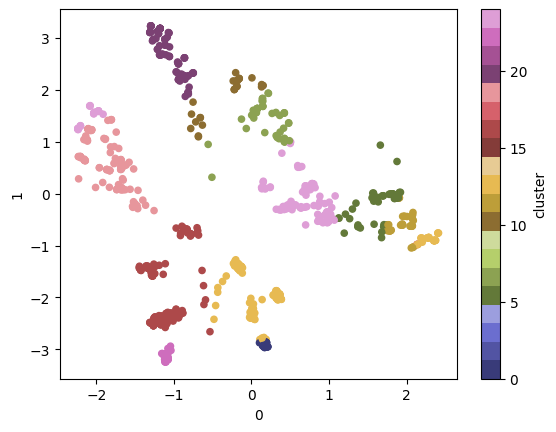

In [23]:
components = pd.DataFrame(model.named_steps.encoder.transform(X))
components['cluster'] = model.named_steps.clustering.predict(components)

pd.DataFrame(components).plot.scatter(x=0, y=1, c='cluster', cmap='tab20b')